
# 🐶🐱 Dog vs Cat Classifier — Beginner Lab
### Hands-On Lab | TensorFlow & Keras | Zero to Working Model

---

> **Who is this for?**  
> You just learned the basics of TensorFlow and Keras. You know what a layer is and what `model.fit()` means.  
> Now you want to build something **real** — a model that looks at a photo and says *"That's a dog!"* or *"That's a cat!"*  
> This lab walks you through every step, one idea at a time. No shortcuts. No "just trust me."

---

**What you will build:**  
A complete image classification model that can look at any dog or cat photo and identify it correctly.

**What you will learn:**
1. How to load real image data in TensorFlow
2. What data augmentation is and why it matters
3. How to build a CNN (Convolutional Neural Network) for images
4. How to train, evaluate and fix your model
5. How to make predictions on new photos

**Time required:** ~45 minutes (plus ~10 min training time)

---



---
## 🗺️ Before We Write Any Code — The Big Picture

Imagine teaching a 3-year-old to tell dogs from cats.  
You don't explain biology. You show them **thousands of pictures** and say *"dog"* or *"cat"* each time.  
After enough examples, they just *know*.

**That is exactly what we are doing with the computer.**

Here is the journey we will take:

```
📸 Raw Images
      ↓
🔧 Resize + Normalize        ← "make all photos the same size and brightness"
      ↓
🔀 Augment (optional)        ← "show flipped/rotated versions to avoid memorizing"
      ↓
🧠 CNN Model                 ← "the brain that learns patterns"
      ↓
📉 Train (minimize loss)     ← "keep adjusting until it gets better"
      ↓
📊 Evaluate on test images   ← "did it really learn, or just memorize?"
      ↓
🔮 Predict on new photo      ← the fun part!
```

Keep this map in mind as you go through each step.



---
## 🛠️ Step 1 — Install & Import Everything

> **Why this step?**  
> Just like a chef needs knives and pans before cooking, we need our tools ready.  
> TensorFlow is the main engine. Keras is the user-friendly layer on top of it.  
> Think of TensorFlow as the car engine, and Keras as the steering wheel + pedals.


In [8]:
# Run this first — installs what we need
# Uncomment the line below if running for the first time
!pip install  tensorflow-datasets 
!pip install importlib-resources



In [6]:
# Run this first — installs what we need
# Uncomment the line below if running for the first time
# !pip install tensorflow tensorflow-datasets matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("✅ TensorFlow version:", tf.__version__)
print("✅ All imports done! Ready to build.")


✅ TensorFlow version: 2.21.0
✅ All imports done! Ready to build.



---
## 📦 Step 2 — Load the Dataset

> **Why this step?**  
> A model is only as good as its training data.  
> We need thousands of labeled images — photos tagged as "cat" or "dog".  
> `tensorflow_datasets` gives us a free, pre-labeled dataset with **23,000+ images**.  
> It downloads automatically. No Kaggle account needed!

> **Train / Val / Test split explained:**  
> - **Train (80%)** → the model learns from these  
> - **Val (10%)** → we check progress during training (model never learns from these)  
> - **Test (10%)** → final exam — completely unseen images  
> 
> Think of it like a student: textbook = train, practice tests = val, real exam = test.


In [9]:
# ── CONFIGURATION — change these to experiment later ─────────────────────────
IMG_SIZE   = 160    # resize every image to 160×160 pixels
BATCH_SIZE = 32     # process 32 images at once during training
# ─────────────────────────────────────────────────────────────────────────────

# Download and split the dataset
(raw_train, raw_val, raw_test), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,   # returns (image, label) pairs
)

CLASS_NAMES = metadata.features['label'].names
print("📌 Classes:", CLASS_NAMES)   # ['cat', 'dog']
print(f"📌 Train images : {len(raw_train):,}")
print(f"📌 Val images   : {len(raw_val):,}")
print(f"📌 Test images  : {len(raw_test):,}")
print(f"\nTotal: {len(raw_train)+len(raw_val)+len(raw_test):,} images")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


Shuffling /Users/akshat/tensorflow_datasets/cats_vs_dogs/incomplete.F3YL9B_4.0.1/cats_vs_dogs-train.tfrecord-[…

Dataset cats_vs_dogs downloaded and prepared to /Users/akshat/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
📌 Classes: ['cat', 'dog']
📌 Train images : 18,610
📌 Val images   : 2,326
📌 Test images  : 2,326

Total: 23,262 images



---
## 👀 Step 3 — Always Look at Your Data First!

> **Why this step?**  
> This is the most skipped step by beginners — and the biggest mistake.  
> Before training anything, look at a sample of your images.  
> Check: Are labels correct? Are some photos blurry or weird? Any surprises?  
> A good data scientist spends MORE time on data than on the model.


I0000 00:00:1780220424.916760  323465 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


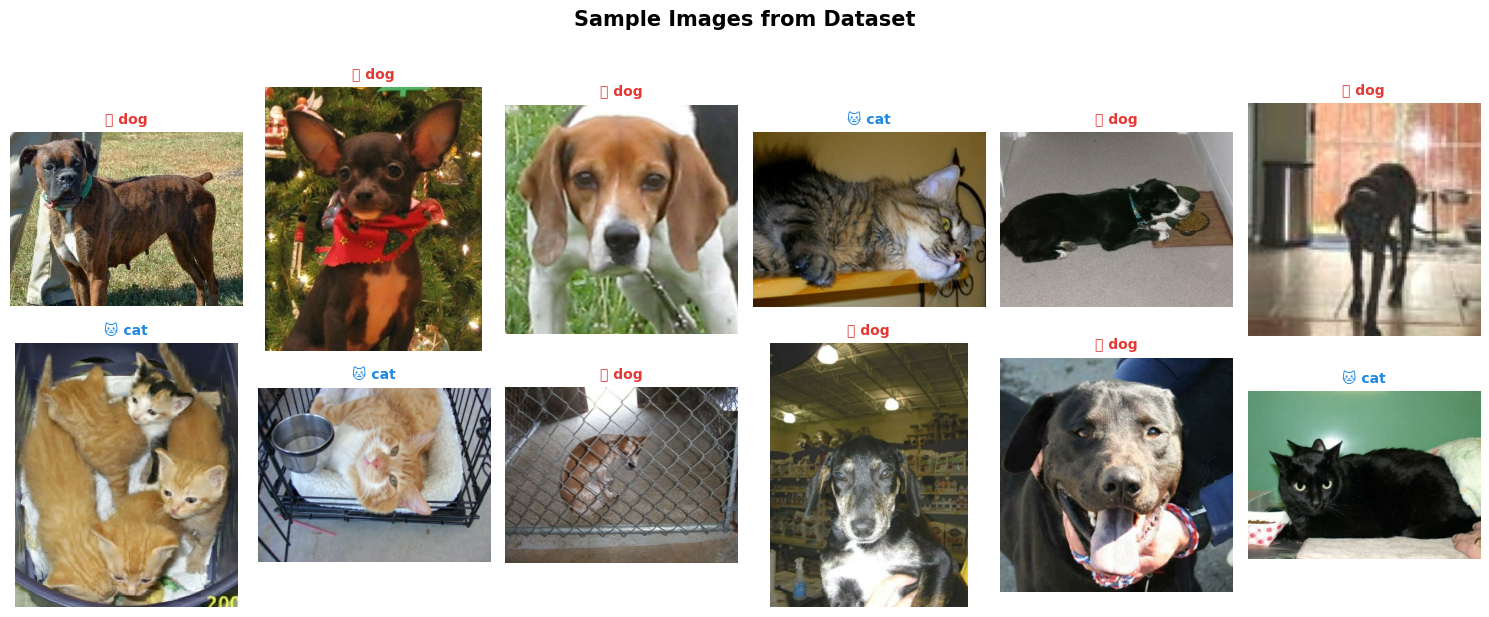


⚠️  Notice: Images come in different sizes!
   We need to resize them all to the same size before training.
   Image shape: (262, 350, 3)  → Label: dog
   Image shape: (409, 336, 3)  → Label: dog
   Image shape: (493, 500, 3)  → Label: dog


In [10]:
plt.figure(figsize=(15, 6))
plt.suptitle("Sample Images from Dataset", fontsize=15, fontweight='bold', y=1.02)

for i, (image, label) in enumerate(raw_train.take(12)):
    ax = plt.subplot(2, 6, i + 1)
    plt.imshow(image)
    
    # Color the title by class
    color = '#E53935' if CLASS_NAMES[label] == 'dog' else '#1E88E5'
    plt.title(f"🐶 {CLASS_NAMES[label]}" if CLASS_NAMES[label] == 'dog' 
              else f"🐱 {CLASS_NAMES[label]}", 
              fontsize=10, fontweight='bold', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Let's also look at image sizes — they are NOT all the same!
print("\n⚠️  Notice: Images come in different sizes!")
print("   We need to resize them all to the same size before training.")
for image, label in raw_train.take(3):
    print(f"   Image shape: {image.shape}  → Label: {CLASS_NAMES[label]}")



---
## 🔧 Step 4 — Preprocess Images (Resize + Normalize)

> **Why resize?**  
> Neural networks expect a fixed input size. Like a form that has exactly 10 boxes — you can't give it 15 or 8.  
> We pick **160×160** pixels. Every image gets resized to this.

> **Why normalize (divide by 255)?**  
> Pixel values go from 0 to 255.  
> Neural networks train faster and better when numbers are between 0 and 1.  
> Dividing by 255 does this. Simple!  
> 
> `255 → 1.0`  `128 → 0.5`  `0 → 0.0`


In [11]:
def preprocess_image(image, label):
    # Step 1: Resize every image to 160×160 pixels
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    # Step 2: Normalize pixel values from [0, 255] to [0.0, 1.0]
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

# Test it on one image
sample_img, sample_label = next(iter(raw_train))
processed_img, _ = preprocess_image(sample_img, sample_label)

print(f"Before processing → shape: {sample_img.shape}, pixel range: [{sample_img.numpy().min()}, {sample_img.numpy().max()}]")
print(f"After processing  → shape: {processed_img.shape}, pixel range: [{processed_img.numpy().min():.2f}, {processed_img.numpy().max():.2f}]")
print("\n✅ All images will now be 160×160 with values between 0 and 1")


Before processing → shape: (262, 350, 3), pixel range: [0, 255]
After processing  → shape: (160, 160, 3), pixel range: [0.00, 1.00]

✅ All images will now be 160×160 with values between 0 and 1



---
## 🔀 Step 5 — Data Augmentation (Making the Model Smarter)

> **The problem without augmentation:**  
> If you always study the SAME 23,000 photos, your model might just *memorize* them.  
> It will do great on training data but fail on new photos. This is called **overfitting**.  
> 
> **Analogy:** Imagine studying for an exam using only 10 specific questions.  
> You memorize those 10 answers perfectly. Then the exam has 10 *different* questions — you fail!  
> 
> **The solution — augmentation:**  
> Randomly flip, rotate, zoom images during training.  
> Now the model sees a dog from different angles, different brightness — just like real life.  
> The model can't memorize because every epoch shows *slightly different* versions.  
> 
> ⚠️ Augmentation is applied ONLY during training, not during validation or testing.


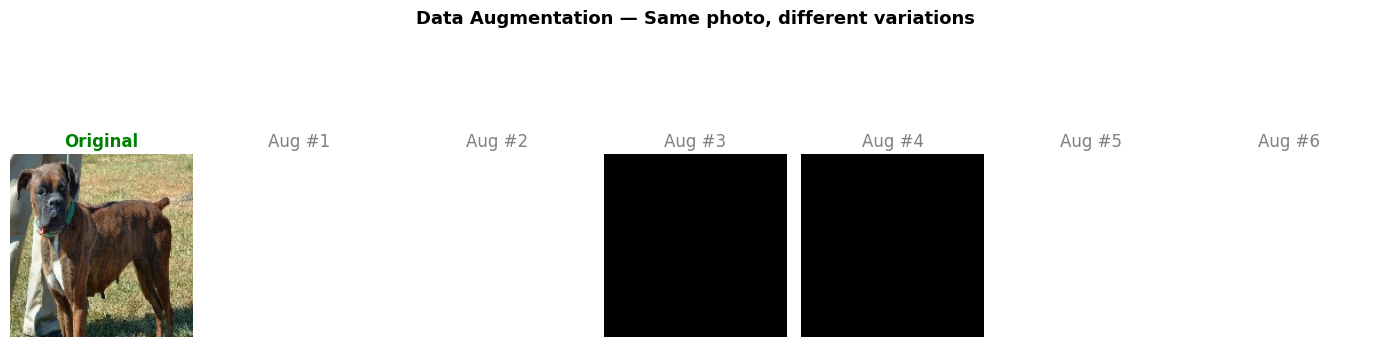


✅ Each time the model trains on this image, it sees a different version!
   This prevents memorization and improves generalization.


In [12]:
# Define augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),       # 50% chance to flip left-right
    layers.RandomRotation(0.10),           # rotate up to ±10%
    layers.RandomZoom(0.10),               # zoom in/out up to 10%
    layers.RandomBrightness(0.10),         # slightly change brightness
], name='data_augmentation')

# VISUALIZE what augmentation looks like
sample_image, _ = next(iter(raw_train.map(preprocess_image)))

plt.figure(figsize=(14, 4))
plt.suptitle("Data Augmentation — Same photo, different variations", 
             fontsize=13, fontweight='bold', y=1.05)

plt.subplot(1, 7, 1)
plt.imshow(sample_image)
plt.title("Original", fontweight='bold', color='green')
plt.axis('off')

for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)[0]
    plt.subplot(1, 7, i + 2)
    plt.imshow(augmented)
    plt.title(f"Aug #{i+1}", color='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Each time the model trains on this image, it sees a different version!")
print("   This prevents memorization and improves generalization.")



---
## ⚙️ Step 6 — Build the Data Pipeline

> **Why a pipeline?**  
> We have 18,000+ training images. We can't load them all into memory at once.  
> `tf.data` loads, preprocesses and feeds images in *batches* while training happens.  
> It's like a factory assembly line — images keep moving in, model keeps training.  
> 
> Key settings:  
> - `shuffle` → randomize order so model doesn't learn order patterns  
> - `batch` → process 32 images at once  
> - `prefetch` → load next batch while model trains on current one (faster!)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(image, label):
    image, label = preprocess_image(image, label)
    image = data_augmentation(image, training=True)  # augment during training only
    return image, label

# Training pipeline — with augmentation + shuffle
train_ds = (raw_train
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .shuffle(buffer_size=1000)   # shuffle 1000 images at a time
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))         # load next batch in background

# Validation & Test pipelines — NO augmentation, just preprocess
val_ds = (raw_val
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

test_ds = (raw_test
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Check what one batch looks like
for images, labels in train_ds.take(1):
    print(f"✅ One batch → Images shape : {images.shape}")
    print(f"              Labels shape : {labels.shape}")
    print(f"              First 5 labels: {[CLASS_NAMES[l] for l in labels[:5].numpy()]}")



---
## 🧠 Step 7 — Understanding the CNN Architecture

> **What is a CNN (Convolutional Neural Network)?**  
> A regular neural network looks at all pixels at once — it misses patterns.  
> A CNN uses small *filters* (like magnifying glasses) that slide across the image,  
> finding patterns — edges, textures, shapes, eyes, fur, etc.  
> 
> **Analogy — A detective examining a crime scene:**  
> - A bad detective looks at the whole room from the door and guesses  
> - A good detective (CNN) examines each corner closely with a magnifying glass,  
>   notes details (scratch marks, fingerprints), then puts them together  
> 
> **The layers in our model:**  
> ```
> Input image (160×160×3)        ← 3 channels = Red, Green, Blue
>      ↓
> Conv2D (32 filters)            ← finds basic edges and lines
> BatchNorm + MaxPool            ← stabilize + shrink image
>      ↓
> Conv2D (64 filters)            ← finds textures (fur, skin)
> BatchNorm + MaxPool
>      ↓
> Conv2D (128 filters)           ← finds shapes (ears, eyes)
> BatchNorm + MaxPool
>      ↓
> Conv2D (256 filters)           ← finds complex features (face structure)
> BatchNorm + MaxPool
>      ↓
> GlobalAveragePooling2D         ← compress to 1D vector
>      ↓
> Dense (128 neurons, ReLU)      ← make final decision
> Dropout (40%)                  ← randomly turn off 40% neurons to prevent overfitting
>      ↓
> Dense (1, Sigmoid)             ← output: 0.0 = cat, 1.0 = dog
> ```


In [ ]:
def build_model():
    model = models.Sequential([
        # ── INPUT ─────────────────────────────────────────────────────────
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # ── BLOCK 1: Find basic edges ──────────────────────────────────────
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        # Conv2D → 32 filters, each 3×3 pixels, slides across image
        # 'relu' → if output is negative, set to 0 (keeps only useful signals)
        layers.BatchNormalization(),
        # BatchNorm → normalize values after each layer (trains faster, more stable)
        layers.MaxPooling2D(pool_size=2),
        # MaxPool → shrink image by half (160→80), keep only strongest signals

        # ── BLOCK 2: Find textures ─────────────────────────────────────────
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),  # 80→40

        # ── BLOCK 3: Find shapes ───────────────────────────────────────────
        layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),  # 40→20

        # ── BLOCK 4: Find complex features ────────────────────────────────
        layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),  # 20→10

        # ── FLATTEN + CLASSIFY ─────────────────────────────────────────────
        layers.GlobalAveragePooling2D(),
        # Average pool all 10×10 feature maps → one number per filter
        # Output: 256 numbers (one per filter)

        layers.Dense(128, activation='relu'),
        # Dense layer: connect all 256 inputs to 128 neurons
        # This is where the final "thinking" happens

        layers.Dropout(0.4),
        # Dropout: randomly turn off 40% of neurons during training
        # Prevents model from becoming too dependent on specific neurons

        layers.Dense(1, activation='sigmoid')
        # Final layer: output 1 number between 0 and 1
        # < 0.5 → Cat  |  >= 0.5 → Dog
    ], name='dog_cat_cnn')

    return model

model = build_model()
model.summary()
print("\n📌 Total parameters = all the 'weights' the model will learn during training")



---
## ⚡ Step 8 — Compile the Model

> **What does compiling mean?**  
> Before training, we tell Keras three things:  
>  
> 1. **Optimizer (Adam)** — How to adjust weights after each wrong answer.  
>    Think of it as a student's study strategy: "I got this wrong, adjust accordingly."  
>  
> 2. **Loss (binary_crossentropy)** — How to measure "how wrong" the prediction was.  
>    `0.0 = cat`, `1.0 = dog`. If model says `0.8` but truth is `0 (cat)`, loss is HIGH.  
>    Training goal = minimize this loss.  
>  
> 3. **Metrics (accuracy)** — What we show on screen during training.  
>    Accuracy = % of correct predictions.


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    # Adam optimizer — good default for most problems
    # learning_rate=0.001 — how big each weight adjustment step is
    # Too high → model overshoots. Too low → trains too slowly.

    loss='binary_crossentropy',
    # Binary = 2 classes (cat or dog)
    # Crossentropy = standard loss for classification problems

    metrics=['accuracy']
    # Show accuracy % during training
)

print("✅ Model compiled!")
print("\nCompile settings:")
print("  Optimizer : Adam (lr=0.001)")
print("  Loss      : binary_crossentropy")
print("  Metrics   : accuracy")



---
## 🛡️ Step 9 — Set Up Callbacks (Training Guards)

> **What are callbacks?**  
> Callbacks are automatic actions that happen during training.  
> Like a coach watching the game and making decisions mid-match.  
>  
> We use two:  
>  
> **EarlyStopping** — "Stop training when the model stops improving"  
> Saves time. Prevents overfitting. If val_loss hasn't improved for 4 epochs → stop.  
> `restore_best_weights=True` → rolls back to the best checkpoint automatically.  
>  
> **ReduceLROnPlateau** — "If stuck, lower the learning rate"  
> If the model hits a plateau (not improving for 2 epochs), cut learning rate by half.  
> Smaller steps = model can find better solutions in tight spots.


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',           # watch validation loss
        patience=5,                   # stop if no improvement for 5 epochs
        restore_best_weights=True,    # revert to best epoch automatically
        verbose=1                     # print a message when it stops
    ),
    ReduceLROnPlateau(
        monitor='val_loss',           # watch validation loss
        factor=0.5,                   # multiply learning rate by 0.5 when stuck
        patience=2,                   # reduce after 2 epochs with no improvement
        min_lr=1e-6,                  # don't go lower than this
        verbose=1
    )
]

print("✅ Callbacks ready!")
print("\nCallbacks configured:")
print("  EarlyStopping     → stops training if val_loss doesn't improve for 5 epochs")
print("  ReduceLROnPlateau → halves learning rate if val_loss stalls for 2 epochs")



---
## 🏋️ Step 10 — Train the Model!

> **What happens during training?**  
> For each batch of 32 images, the model:  
> 1. Makes predictions (forward pass)  
> 2. Calculates how wrong it was (loss)  
> 3. Figures out how to adjust weights to be less wrong (backpropagation)  
> 4. Updates the weights (optimizer step)  
>  
> One **epoch** = going through ALL training images once.  
> We run up to 30 epochs. EarlyStopping will stop early if needed.  
>  
> **Expected training time:** ~5-15 minutes depending on your machine.  
> On GPU: much faster! On CPU: be patient. ☕


In [ ]:
print("🚀 Starting training... this may take a few minutes.")
print(f"   Training on {len(raw_train):,} images | Validating on {len(raw_val):,} images")
print(f"   Batch size: {BATCH_SIZE} | Max epochs: 30")
print("─" * 60)

history = model.fit(
    train_ds,                  # training data
    epochs=30,                 # max number of epochs
    validation_data=val_ds,    # check on validation set after each epoch
    callbacks=callbacks,       # early stopping + lr scheduler
    verbose=1                  # show progress bar
)

print("\n✅ Training complete!")
print(f"   Epochs run: {len(history.history['accuracy'])}")
print(f"   Best val accuracy: {max(history.history['val_accuracy']):.2%}")



---
## 📊 Step 11 — Visualize Training Progress

> **Reading the training curves:**  
>  
> **Good training (what we want):**  
> - Both train and val accuracy go UP together  
> - Both train and val loss go DOWN together  
>  
> **Overfitting (bad):**  
> - Train accuracy keeps going up  
> - Val accuracy stops improving or drops  
> - Model memorized training data, fails on new data  
>  
> **Underfitting (also bad):**  
> - Both accuracies stay low  
> - Model is too simple or didn't train long enough


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy Plot ────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history.history['accuracy'],     
             'b-o', label='Train Accuracy', markersize=4)
axes[0].plot(epochs_range, history.history['val_accuracy'], 
             'r-o', label='Val Accuracy', markersize=4, linestyle='--')
axes[0].set_title('Model Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

# ── Loss Plot ────────────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history.history['loss'],     
             'b-o', label='Train Loss', markersize=4)
axes[1].plot(epochs_range, history.history['val_loss'], 
             'r-o', label='Val Loss', markersize=4, linestyle='--')
axes[1].set_title('Model Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnosis
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap             = final_train_acc - final_val_acc

print(f"\n📌 Final Train Accuracy : {final_train_acc:.2%}")
print(f"📌 Final Val Accuracy   : {final_val_acc:.2%}")
print(f"📌 Gap (overfit check)  : {gap:.2%}")
if gap > 0.10:
    print("⚠️  Gap > 10% → possible overfitting. Try more augmentation or more dropout.")
else:
    print("✅ Gap is small → model is generalizing well!")



---
## 🧪 Step 12 — Final Evaluation on Test Set

> **Why use a separate test set?**  
> The model has NEVER seen these images during training or validation.  
> This is the real-world simulation.  
> A model that scores 95% on training but 70% on test is not actually good!


In [ ]:
print("Evaluating on unseen test images...")
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"\n{'='*40}")
print(f"  ✅ Test Loss     : {test_loss:.4f}")
print(f"  ✅ Test Accuracy : {test_acc:.2%}")
print(f"{'='*40}")

if test_acc >= 0.80:
    print("\n🎉 Great job! 80%+ accuracy on unseen images.")
elif test_acc >= 0.70:
    print("\n👍 Decent! 70-80%. Try transfer learning (Step 14) to improve.")
else:
    print("\n⚠️  Below 70%. Check your data pipeline and try more epochs.")



---
## 🔍 Step 13 — See What the Model Predicts

> Now the fun part — let's actually see the model making predictions!  
> Green title = correct prediction. Red title = wrong prediction.


In [ ]:
# Get one batch from test set and visualize predictions
images_batch, labels_batch = next(iter(test_ds))
predictions = model.predict(images_batch, verbose=0).flatten()

plt.figure(figsize=(16, 8))
plt.suptitle('Model Predictions on Test Images', fontsize=14, fontweight='bold', y=1.02)

for i in range(16):
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(images_batch[i])

    pred_prob   = predictions[i]
    pred_label  = 'dog' if pred_prob >= 0.5 else 'cat'
    true_label  = CLASS_NAMES[labels_batch[i].numpy()]
    confidence  = pred_prob if pred_label == 'dog' else (1 - pred_prob)
    is_correct  = pred_label == true_label

    emoji = '🐶' if pred_label == 'dog' else '🐱'
    color = '#2E7D32' if is_correct else '#C62828'
    mark  = '✅' if is_correct else '❌'

    plt.title(f"{mark} {emoji} {pred_label}\n{confidence:.0%} conf", 
              fontsize=8, color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Count correct
correct = sum(1 for p, l in zip(predictions, labels_batch.numpy())
              if (p >= 0.5) == bool(l))
print(f"\n✅ Correct in this batch: {correct}/32 = {correct/32:.0%}")



---
## 🔮 Step 14 — Predict on Your Own Photo!

> This is the final goal — use the trained model on a real photo from your computer.  
>  
> **How to use:**  
> 1. Upload your dog/cat image to the same folder as this notebook  
> 2. Replace `'your_image.jpg'` with your filename  
> 3. Run the cell!


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_my_image(image_path):
    """
    Predict if your image is a dog or cat.
    
    Usage:
        result = predict_my_image('my_dog.jpg')
        result = predict_my_image('path/to/cat_photo.png')
    """
    # Load and resize the image
    img = keras_image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    
    # Convert to numpy array and normalize
    img_array = keras_image.img_to_array(img) / 255.0
    
    # Add batch dimension: (160,160,3) → (1,160,160,3)
    # Model expects batches, even if it's just 1 image
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Get prediction (a number between 0 and 1)
    prediction = model.predict(img_batch, verbose=0)[0][0]
    
    # Interpret result
    label      = '🐶 Dog' if prediction >= 0.5 else '🐱 Cat'
    confidence = prediction if prediction >= 0.5 else (1 - prediction)
    
    # Show image with prediction
    plt.figure(figsize=(5, 5))
    plt.imshow(keras_image.load_img(image_path))
    plt.title(f"Prediction: {label}\nConfidence: {confidence:.1%}",
              fontsize=14, fontweight='bold',
              color='#C62828' if 'Dog' in label else '#1565C0')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Result     : {label}")
    print(f"Confidence : {confidence:.1%}")
    print(f"Raw score  : {prediction:.4f}  (≥0.5 = dog, <0.5 = cat)")
    return {'label': label, 'confidence': f'{confidence:.1%}'}


# ── TO USE: Uncomment and change the filename ──────────────────────────────
# result = predict_my_image('my_dog.jpg')
# result = predict_my_image('my_cat.png')

print("✅ predict_my_image() function is ready!")
print("   Uncomment the last two lines and replace with your image filename.")



---
## 💾 Step 15 — Save the Trained Model

> Training takes time! Save the model so you don't have to retrain next time.  
> Just load it and go straight to predictions.


In [ ]:
# Save the model
model.save('dog_cat_model.keras')
print("✅ Model saved as 'dog_cat_model.keras'")

# ── How to reload later ──────────────────────────────────────────────────────
# from tensorflow.keras.models import load_model
# model = load_model('dog_cat_model.keras')
# result = predict_my_image('any_photo.jpg')
# 
# That's it! No need to retrain.



---
## 🎓 You Did It! — Summary & Next Steps

### What You Built Today

| Component | What it does |
|-----------|-------------|
| `preprocess_image()` | Resizes + normalizes every image |
| `data_augmentation` | Flip, rotate, zoom to prevent memorization |
| `tf.data` pipeline | Efficient batched data loading |
| CNN model (4 blocks) | Learns patterns: edges → textures → shapes → faces |
| EarlyStopping | Stops training at the right time |
| ReduceLROnPlateau | Fine-tunes learning rate automatically |
| `predict_my_image()` | Runs your photo through the trained model |

---

### 🚀 Next Steps to Try

**Improve accuracy:**
- Try `IMG_SIZE = 224` (more detail, more compute)
- Add one more Conv block with 512 filters
- Try a different optimizer: `SGD` instead of `Adam`

**Transfer Learning (big jump in accuracy):**
```python
base = MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base.trainable = False
# Add your own head on top — gets 90%+ accuracy easily!
```

**Try other datasets:**
- Flowers (5 classes)
- CIFAR-10 (10 classes)
- Your own photos!

---

> 💡 **Key Takeaway:**  
> Machine learning is not magic. It's just:  
> **Good data + Right architecture + Enough training + Honest evaluation**  
> You now know how to do all four. 🎉
